<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [1]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
except ImportError:
    # Not running in Colab
    in_google_colab = False
    pass

In [2]:
import pandas as pd
import pyarrow  # ensures pandas can read/write parquet
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm
from IPython.display import display

# Loading and Exporting
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

## Load Data

In [3]:
dataset_name = "Labeled_Datasets/Ecuador"  # folder path
file_name = f"Ecuador_part_5.gzip.parquet"  # file name

# if run local: put data in "../data/<dataset_name>/<file_name>"
# Recommended: working directory is: "Backbone-Graph/src"

In [4]:
from pathlib import Path

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster\Local
else:
    # Recommended: working directory is: "Backbone-Graph/src"
    dataset_path = Path("../data") / dataset_name / file_name
    print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# Load the parquet file
df = pd.read_parquet(dataset_path)

# for testing
# df = df.sample(n=1000, random_state=42).copy()

Running on local/cluster.
Loading data from: ../data/Labeled_Datasets/Ecuador/Ecuador_part_5.gzip.parquet


## Output Path


In [5]:
from datetime import datetime
today = datetime.now().strftime("%Y_%m_%d")


dataset_path = Path(dataset_path)


if in_google_colab:
  output_folder_path = (dataset_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / dataset_path.parent.name / dataset_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = file_name.split(".")[0]
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes / today
  # Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"



output_folder_path.mkdir(parents=True, exist_ok=True) # Createst the output directory if needed

print(f"output_folder_path = {output_folder_path}")

output_folder_path = ../results/Labeled_Datasets/Ecuador/Ecuador_part_5/2025_12_01


In [6]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
233553,8210be550701982a1d35c9bde38f12e1f8fe77f648,Gracias mi amado #Perú por toda la preocupació...,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,es,None,None,2015-09-17 23:10:47,5fa9123f60bfeaf7b39b3bac238a7569b805453a34,Diaguita✨ HASTA QUE LA DIGNIDAD SE HAGA COSTUM...,350,817,2010-11-30,True,99295260431455d4adacb29e5a7cccfcca0fef6cf3,62a03140d1d59c81be4dee8779deb6f129f4fadec3,"[Perú, chile, FuerzaChile]",[],[99295260431455d4adacb29e5a7cccfcca0fef6cf3],True
209427,a9c6d650bc5d83464b950b2bde0b927ef60da25ba9,@fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda I ...,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,en,3f579e2e963af90ff34169bc74e56723fb9e952ec2,fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda,2015-05-19 23:48:59,6b33b674860ff49788076a365f06a197764355ea19,"Ever since May 30, 2017 the #HolySpirit has me...",1473,4219,2009-03-01,False,None,None,"[HolySpirit, blessedunion]",[],[fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda],True
200199,a8dd204c446ffb7047c57a374dd70b8979b0afa31e,"""@c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5: ...",a20fd3edddb315e8a4abfdc03c03ce2a6bf795e456,es,None,None,2015-03-05 04:54:13,961d03b0ff90a98497c4033b11bf6440f7daf1d86f,Madre Venezolana Ingeniera Docente Universitar...,3488,3811,2009-10-08,False,None,None,[],[https://a8b4f75c94576ea8ba39a908d45515bfa1e20...,[c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5],True
212447,482825068aa5fefaa6d2dd88e4faf99336383d79ea,17 new followers in the last week and it is mo...,28e5b083867d3363db63617cc0f3cfd106abf13d6d,en,None,None,2015-06-13 00:22:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,False,None,None,[],[https://8cd98e38678d50286ec04371d9054599a55f1...,[],False
239489,45b25d23c7914d72520973703afad4713333344d0d,[Comunicado]\nAnte arremetida calumniosa y ate...,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,es,None,None,2015-10-19 16:21:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,True,61a572ca33176e21f363a95acfd60c662647aeb56d,bb6e2711b637c97ac1c713a007960a4733bc9ad133,[Asambleísta],[],"[61a572ca33176e21f363a95acfd60c662647aeb56d, 8...",False


# Dataset Statistics

In [7]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]

print(f"{'df shape:':<40} {df.shape}")
print(f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)")


print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

df shape:                                (100, 19)
df posts with hashtags # shape:          (45, 19)  (45.00%)
df posts with account_mentions @ shape:  (71, 19)  (71.00%)
df posts with urls shape:                (63, 19)  (63.00%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     

# Clean Text

In [8]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token


In [9]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [10]:
df["clean_post_text"] = df["post_text"].apply(clean_text)

## Remove Enttities Enteties

In [11]:
import re
import pandas as pd

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_enteties(text: str) -> str:
    """
    Lightly clean a social-media post while keeping it natural
    for machine translation.

    Operations:
    - Replace URLs with <URL>
    - Replace @username with <USER>
    - Turn #hashtag into 'hashtag' (drop the #)
    - Collapse repeated whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = str(text).lower()

    # 1. Normalize URLs
    text = URL_RE.sub("<URL>", text)

    # 2. Normalize mentions
    text = MENTION_RE.sub("<USER>", text)

    # 3. Normalize hashtags: "#Ecuador2025" -> "Ecuador2025"
    text = HASHTAG_RE.sub(r"\1", text)

    # 4. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text).strip()

    return text

In [12]:
df["clean_text_no_enteties"] = df["post_text"].astype(str).apply(clean_enteties)

In [13]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

df[["post_text", "clean_text_no_enteties"]].sample(n=20)

,post_text,clean_text_no_enteties
209427,@fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda I can relate w/George my upcoming marriage proposal truly a surprise BUT it's endorsed by d #HolySpirit of God!! #blessedunion!!,<USER> i can relate w/george my upcoming marriage proposal truly a surprise but it's endorsed by d holyspirit of god!! blessedunion!!
210822,Let's give some positive vibes &amp; #Support 2 @f8265eba05e3a55d057c3fb22a7d427b939d3fea91 &amp; #Palestine in the upcoming #FIFA vote! ☺\n\n#RedCardIsrael https://6d8cbb605cb9e91e73cfcc088b07d14f604447017f,let's give some positive vibes &amp; support 2 <USER> &amp; palestine in the upcoming fifa vote! ☺ redcardisrael <URL>
234304,https://9e69054002d6e3811a3f52079ed79e212fbed49191 Вот полезный сайт здесь,<URL> вот полезный сайт здесь
200199,"""@c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5: Comandante Hugo Chávez, precursor de la liberación de América Latina https://a8b4f75c94576ea8ba39a908d45515bfa1e207fefb https://824bed881d27c43882779490dab8bef2ea27b2bc9b""","""<USER>: comandante hugo chávez, precursor de la liberación de américa latina <URL> <URL>"
246734,iCoño….. Julio Borges esta bastante seguro de lo que dice. #6D,icoño….. julio borges esta bastante seguro de lo que dice. 6d
248492,#ECUADOR SÁBADO 19 DICIEMBRE A LA 1 PM SE EXTRAVIO MI PERRO¡SECTOR DE LA MARIANA DE JESÚS Y AMAZONAS¡FB: David Bone https://007ef4188ea58589130059c807c1c60cf66b5f5dad,ecuador sábado 19 diciembre a la 1 pm se extravio mi perro¡sector de la mariana de jesús y amazonas¡fb: david bone <URL>
242111,"Sonríe , hasta con dientes, y que se joda la gente.","sonríe , hasta con dientes, y que se joda la gente."
218619,Ay falta poco para mis 15 😔💔,ay falta poco para mis 15 😔💔
224712,.@e49ab1b32c7e0809c78af387d19c278fbfd4d7b97a on site for #DrivenHunt #Limpopo #CannedShooting Beaters with dogs! No hope of escape. https://681eaf90ace4c18962b54ab19fb641556417b4de4e,.<USER> on site for drivenhunt limpopo cannedshooting beaters with dogs! no hope of escape. <URL>
215118,https://3e959fe4ae25bfa768bb963cc89782c1927c48d59d,<URL>


# Translation to English

In [14]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str) -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in mup return the same language code.
    Args:
        lang_code (str): Post language code.
    Returns:
        str: NLLB-200 language code.
    """
    nlln_mapping = {
    # Europe
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "pt": "por_Latn",   # Portuguese
    "fr": "fra_Latn",   # French
    "de": "deu_Latn",   # German
    "it": "ita_Latn",   # Italian
    "nl": "nld_Latn",   # Dutch
    "ru": "rus_Cyrl",   # Russian
    "pl": "pol_Latn",   # Polish
    "sv": "swe_Latn",   # Swedish
    "ca": "cat_Latn",    # Catalan
    "cy": "cym_Latn",    # Welsh
    "et": "est_Latn",    # Estonian

    # Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "tr": "tur_Latn",   # Turkish
    "fa": "pes_Arab",   # Persian/Farsi

    # South Asia
    "hi": "hin_Deva",   # Hindi
    "ur": "urd_Arab",   # Urdu
    "bn": "ben_Beng",   # Bengali

    # East Asia
    "zh": "zho_Hans",   # Chinese Simplified
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean

    # Southeast Asia
    "vi": "vie_Latn",   # Vietnamese
    "id": "ind_Latn",   # Indonesian (modern code)
    "in": "ind_Latn",   # Indonesian (legacy ISO code)
    "tl": "tgl_Latn",   # Tagalog (Philippines)

    # Africa
    "sw": "swh_Latn",   # Swahili

    # Americas
    "qu": "quy_Latn",   # Quechua (Ayacucho)
}


    if lang_code in nlln_mapping:
        return nlln_mapping[lang_code]
    else:
        return lang_code

In [15]:
df["post_language"] = df["post_language"].apply(map_to_nllb_code)

In [16]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, max_length=1000, batch_size=16)

Using device: cuda


Device set to use cuda


In [17]:
from tqdm.auto import tqdm


def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "clean_text_no_enteties",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
) -> pd.DataFrame:
    """
    Translate df[text_col] → target_lang using NLLB pipeline.

    If src_lang == target_lang and backtranslate_same_lang=True,
    perform back-translation: target_lang → pivot_lang → target_lang.

    Args:
        df (pd.DataFrame):
            Input DataFrame containing text and language labels.
        translation_pipe (transformers.pipeline):
            Pre-loaded translation pipeline (e.g., NLLB-200).
        text_col (str):
            Column containing original text.
        lang_col (str):
            Column containing language codes matching the pipeline
            (e.g., "spa_Latn", "eng_Latn").
        out_col (str):
            Column name for the translated output.
        target_lang (str):
            Target language code (default: "eng_Latn").
        pivot_lang (str):
            Pivot language code for back-translation (default: "spa_Latn").
        backtranslate_same_lang (bool):
            If True, back-translate rows where src_lang == target_lang.

    Returns:
        pd.DataFrame:
            A DataFrame with the same index as df and one column (out_col).
    """

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None

    # Iterate per language with progress bar
    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):

        # Build a list[str]
        texts = group[text_col].astype(str).tolist()

        # Keep the original indexes so we can assign back later
        indexes = group.index.to_list()

        translated = []  # empty means "no translation done"

        # Case 1: normal translation src_lang -> target_lang
        if src_lang != target_lang:
            print(f"{len(texts)} posts: {src_lang} → {target_lang}")
            outputs = translation_pipe(
                texts,
                src_lang=src_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in outputs]

        # Case 2: back-translation target_lang -> pivot_lang -> target_lang
        if (src_lang == target_lang) and backtranslate_same_lang:
            print(f"{len(texts)} posts: {target_lang} → {pivot_lang} → {target_lang}")
            pivot_outputs = translation_pipe(
                texts,
                src_lang=target_lang,
                tgt_lang=pivot_lang,
            )
            pivot_texts = [o["translation_text"] for o in pivot_outputs]

            back_outputs = translation_pipe(
                pivot_texts,
                src_lang=pivot_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in back_outputs]

        if translated:
            result_df.loc[indexes, out_col] = translated

    return result_df

In [18]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.drop(columns=["translated_post"], errors="ignore") # Drop the old column if exist
df = df.join(translated_df)

df shape: (100, 21)


Translating by language:   0%|          | 0/11 [00:00<?, ?it/s]

1 posts: arb_Arab → eng_Latn
1 posts: bg → eng_Latn
1 posts: cat_Latn → eng_Latn
17 posts: eng_Latn → spa_Latn → eng_Latn
1 posts: ht → eng_Latn
2 posts: por_Latn → eng_Latn
11 posts: rus_Cyrl → eng_Latn
59 posts: spa_Latn → eng_Latn
1 posts: swe_Latn → eng_Latn


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


5 posts: und → eng_Latn
1 posts: vie_Latn → eng_Latn


In [19]:
pd.set_option("display.width", 3000)
pd.set_option("display.max_colwidth", 1500)

df.sample(10)[["clean_text_no_enteties", "translated_post"]]

,clean_text_no_enteties,translated_post
244305,infomagap | 20 agricultores de nuevaesperanza se capacitan en elaboración abono orgánico biol stodgotsáchilas <URL>,20 new hop farmers trained in organic fertilizer biol stodgotsachilas <URL>
221123,apagar las estrellas y extinguir el sol es el capricho del ocaso. felizcumplegustavocerati <URL>,To put out the stars and extinguish the sun is the whim of the sunset.
201812,la maquinaria d <USER> llega a bucay(matilde esther)para atender emergencia de río sanantonio <USER> h…,The machinery arrives at bucay to respond to the Sanantonio River emergency.
212609,<USER> creo que va a tener dificultades para bajar y apresar a todos por semejante falta de respeto...,I think he's going to have a hard time getting down and arresting everyone for such disrespect...
215908,ecuadorteabraza: oración final en la misa campal en el parque bicentenario en quito. <URL>,Equadorteabraza: final prayer at the campal mass in the Bicentennial Park in Quito.
228102,<USER> на редкость очень хорошая подборка. однозначно плюс. <URL>,<USER> is rarely a very good selection. Definitely a plus. <URL>
217746,al parecer hay problemas tecnicos otratourseattle,Apparently there are technical problems elsewhere.
215079,<USER> <USER> <URL> <URL>,<undUSER> <USER> <URL> <URL> <URL>
246734,icoño….. julio borges esta bastante seguro de lo que dice. 6d,Icon... July Borges is pretty sure of what she's saying.
242684,"más allá d estar o no d acuerdo con este anuncio, ha sido la estocada final para la opo. se quedaron sin propuesta! https…","Beyond whether or not I agree with this announcement, it has been the final blow to the OPP."


# Remove Engllish Stopwords

In [20]:
from nltk.corpus import stopwords
import nltk

In [21]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
df["clean_post_text"] = df["clean_post_text"].apply(remove_stopwords)

In [23]:
df[["post_text", "clean_post_text"]].head(20)

,post_text,clean_post_text
233553,Gracias mi amado #Perú por toda la preocupación en este lamentable desastre natural ocurrido en #chile! 🙌 #FuerzaChile,gracias mi amado hashtag_perú por toda la preocupación en este lamentable desastre natural ocurrido en hashtag_chile ! emoji_raising_hands hashtag_fuerzachile
209427,@fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda I can relate w/George my upcoming marriage proposal truly a surprise BUT it's endorsed by d #HolySpirit of God!! #blessedunion!!,mention_fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda relate w/george upcoming marriage proposal truly surprise endorsed hashtag_holyspirit god!! hashtag_blessedunion !!
200199,"""@c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5: Comandante Hugo Chávez, precursor de la liberación de América Latina https://a8b4f75c94576ea8ba39a908d45515bfa1e207fefb https://824bed881d27c43882779490dab8bef2ea27b2bc9b""",""" mention_c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5 : comandante hugo chávez, precursor de la liberación de américa latina url_a8b4f75c94576ea8ba39a908d45515bfa1e207fefb url_824bed881d27c43882779490dab8bef2ea27b2bc9b"""
212447,"17 new followers in the last week and it is more than just stats, I use it for growing my account! Try it https://8cd98e38678d50286ec04371d9054599a55f199854","17 new followers last week stats, use growing account! try url_8cd98e38678d50286ec04371d9054599a55f199854"
239489,[Comunicado]\nAnte arremetida calumniosa y atentatoria a dignidad y buen nombre d #Asambleísta @8339a481f9ccf3caef7b1dde5f8920f7f149950160 @f96aa1017e8b8b26d3276009c97035ccb92711eaf0 http…,[comunicado] ante arremetida calumniosa atentatoria dignidad buen nombre hashtag_asambleísta mention_8339a481f9ccf3caef7b1dde5f8920f7f149950160 mention_f96aa1017e8b8b26d3276009c97035ccb92711eaf0 http…
242724,#JeSuisParis #JeSuisParis #JeSuisParis #JeSuisParis ####################,hashtag_jesuisparis hashtag_jesuisparis hashtag_jesuisparis hashtag_jesuisparis ####################
210822,Let's give some positive vibes &amp; #Support 2 @f8265eba05e3a55d057c3fb22a7d427b939d3fea91 &amp; #Palestine in the upcoming #FIFA vote! ☺\n\n#RedCardIsrael https://6d8cbb605cb9e91e73cfcc088b07d14f604447017f,let's give positive vibes &amp; hashtag_support 2 mention_f8265eba05e3a55d057c3fb22a7d427b939d3fea91 &amp; hashtag_palestine upcoming hashtag_fifa vote! emoji_smiling_face hashtag_redcardisrael url_6d8cbb605cb9e91e73cfcc088b07d14f604447017f
249498,Very Interesting! Child-seat manufacturer Dorel utilizes the same technology found in @cad8661b7fb8592d186751c40e4852617a9d839b93 race seats. https://7d9a660591f0208084f609c322195006a8598de004,interesting! child-seat manufacturer dorel utilizes technology found mention_cad8661b7fb8592d186751c40e4852617a9d839b93 race seats. url_7d9a660591f0208084f609c322195006a8598de004
204144,"Hoy en #NoticiasTVV Declaraciones del dirigente @df7806685b99a2614c24e63aab490130ca10c395db, del presidente de Empresas Polar, Lorenzo Mendonza (1/2)","hoy en hashtag_noticiastvv declaraciones del dirigente mention_df7806685b99a2614c24e63aab490130ca10c395db , del presidente de empresas polar, lorenzo mendonza (1/2)"
236958,"""Aquellos de luto, podrán vestir luto eterno, porque el pasado no volverá"" @2087399d0b911ed0bb43aa9da21d7301f0a077e56c #ELAP2015","""aquellos de luto, podrán vestir luto eterno, porque el pasado volverá"" mention_2087399d0b911ed0bb43aa9da21d7301f0a077e56c hashtag_elap2015"


# English Topic Clustering

## Utils


In [24]:
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums: [topic, total_count, io_Count, legitimate_posts, io_percent].
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [25]:
def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_folder_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]
    io_percent = topic_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    # Add IO percentage text
    ax = plt.gca()
    for x, io, legit, pct in zip(topics, io_count, legitimate_count, io_percent):
        total_height = io + legit
        ax.text(
            x,
            total_height + 1,              # slightly above the bar
            f"{pct:.1f}%",                 # format like 23.5%
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    plt.title(f"Post Count per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.text(0.98, 0.82, f"Total posts: {topic_stats['total_count'].sum()}", ha="right", va="bottom", transform=plt.gca().transAxes)
    plt.xticks(topics)
    plt.grid(axis="y")
    plt.legend()
    plt.tight_layout()


    if output_folder_path:
        plot_file_path = output_folder_path / (f"{model_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")

    plt.show()

In [26]:
clean_posts_text_lst = df["clean_post_text"].to_list()

In [27]:
from sklearn.preprocessing import normalize

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

## BERTopic

In [28]:
def english_BERTopic_modeling(posts_text_lst, embeddings, output_folder_path= "", min_topic_size=50):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    # save model to folder
    if output_folder_path:
        topic_model.save(output_folder_path / "BERTopic_model")
        print(f"BERTopic model is saved to {output_folder_path}")

    return topics, probs, topic_model


In [29]:
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(clean_posts_text_lst, embeddings, output_folder_path)

df["BERTopic_topic"] = BERTopic_topic

BERTopic_model.get_topic_info()

2025-12-01 21:59:07,189 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-01 21:59:15,129 - BERTopic - Dimensionality - Completed ✓
2025-12-01 21:59:15,129 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-01 21:59:15,134 - BERTopic - Cluster - Completed ✓
2025-12-01 21:59:15,136 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-01 21:59:15,143 - BERTopic - Representation - Completed ✓
2025-12-01 21:59:15,148 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


BERTopic model is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_5/2025_12_01


,Topic,Count,Name,Representation,Representative_Docs
0,-1,100,-1_de_la_en_el,"[de, la, en, el, que, se, con, las, por, para]","[hashtag_ecuador sábado 19 diciembre la 1 pm se extravio mi perro¡sector de la mariana de jesús amazonas¡fb: david bone url_007ef4188ea58589130059c807c1c60cf66b5f5dad, enferma la gente con sus problemas religiosos. la gente olvida que el amor está siempre por delante de todo, que moreno será el candidato en 2017. el peor de todos: que pasarán las enmiendas. entendamos: dejará el poder total por las buenas.]"


plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_5/2025_12_01/BERTopic_topic_clustering.png


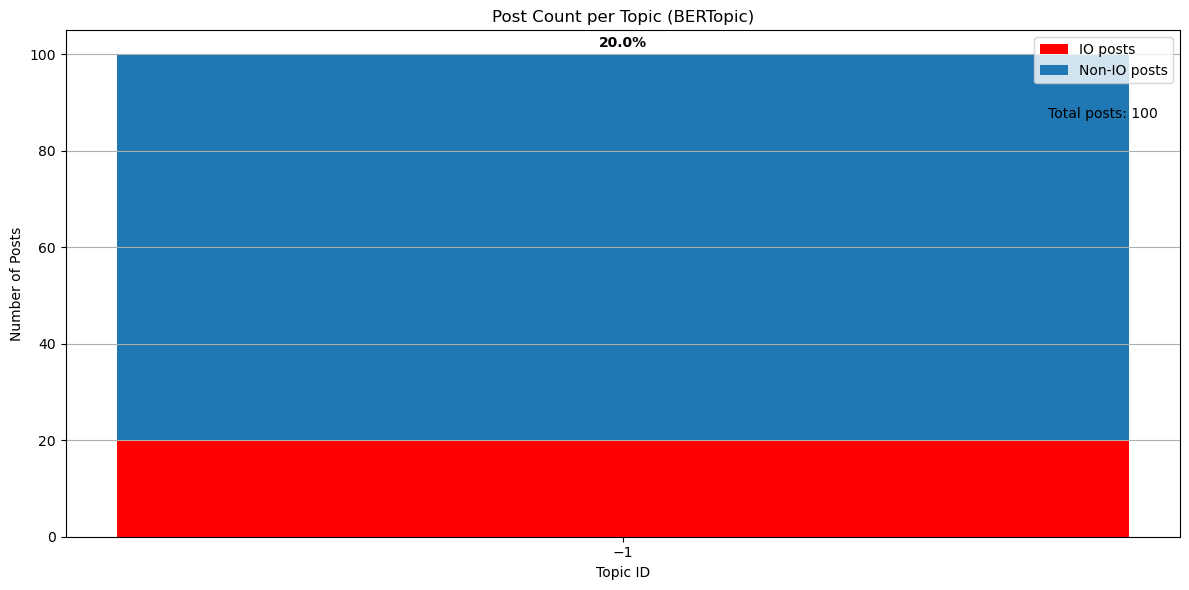

In [30]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

In [31]:
from IPython.display import display

try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

Not enough topics for visualization
Error: arrays used as indices must be of integer (or boolean) type


## K-Means

In [32]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def auto_kmeans_topics(embeddings, k_min=4, k_max=40, step = 2):
    best_k = None
    best_score = -1
    best_labels = None

    for k in range(k_min, k_max + 1, step):
        print(f"Trying k={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [33]:
# Add to df
labels, best_k = auto_kmeans_topics(embeddings)
df["K_Means_topic"] = labels
print(f"Best k: {best_k}")
df.head()

Trying k=4
Trying k=6
Trying k=8
Trying k=10
Trying k=12
Trying k=14
Trying k=16
Trying k=18
Trying k=20
Trying k=22
Trying k=24
Trying k=26
Trying k=28
Trying k=30
Trying k=32
Trying k=34
Trying k=36
Trying k=38
Trying k=40
Best k: 4


,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,reposted_postid,hashtags,urls,account_mentions,is_control,clean_post_text,clean_text_no_enteties,translated_post,BERTopic_topic,K_Means_topic
233553,8210be550701982a1d35c9bde38f12e1f8fe77f648,Gracias mi amado #Perú por toda la preocupación en este lamentable desastre natural ocurrido en #chile! 🙌 #FuerzaChile,15592fcc82d5064a8f4a3b89774e6cd0bbd2118aa0,spa_Latn,None,None,2015-09-17 23:10:47,5fa9123f60bfeaf7b39b3bac238a7569b805453a34,Diaguita✨ HASTA QUE LA DIGNIDAD SE HAGA COSTUMBRE ♥️🇨🇱,350,...,62a03140d1d59c81be4dee8779deb6f129f4fadec3,"[Perú, chile, FuerzaChile]",[],[99295260431455d4adacb29e5a7cccfcca0fef6cf3],True,gracias mi amado hashtag_perú por toda la preocupación en este lamentable desastre natural ocurrido en hashtag_chile ! emoji_raising_hands hashtag_fuerzachile,gracias mi amado perú por toda la preocupación en este lamentable desastre natural ocurrido en chile! 🙌 fuerzachile,Thank you my beloved Peru for all your concern about this unfortunate natural disaster in Chile!,-1,0
209427,a9c6d650bc5d83464b950b2bde0b927ef60da25ba9,@fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda I can relate w/George my upcoming marriage proposal truly a surprise BUT it's endorsed by d #HolySpirit of God!! #blessedunion!!,62010408238d4a0f958ec97eec3db0a4f69bcd0d11,eng_Latn,3f579e2e963af90ff34169bc74e56723fb9e952ec2,fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda,2015-05-19 23:48:59,6b33b674860ff49788076a365f06a197764355ea19,"Ever since May 30, 2017 the #HolySpirit has me thinking 24/7 about my 1256acf859fa5d3b9cd0c87aa7930115c2bb9cb0cb cuz politics ruined my career Brooke accepted my #HolySpirit #marriageproposal",1473,...,None,"[HolySpirit, blessedunion]",[],[fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda],True,mention_fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda relate w/george upcoming marriage proposal truly surprise endorsed hashtag_holyspirit god!! hashtag_blessedunion !!,<USER> i can relate w/george my upcoming marriage proposal truly a surprise but it's endorsed by d holyspirit of god!! blessedunion!!,<USER> I can relate to George my next marriage proposal really a surprise but it's backed by God's holy spirit!! blessed union!!,-1,3
200199,a8dd204c446ffb7047c57a374dd70b8979b0afa31e,"""@c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5: Comandante Hugo Chávez, precursor de la liberación de América Latina https://a8b4f75c94576ea8ba39a908d45515bfa1e207fefb https://824bed881d27c43882779490dab8bef2ea27b2bc9b""",a20fd3edddb315e8a4abfdc03c03ce2a6bf795e456,spa_Latn,None,None,2015-03-05 04:54:13,961d03b0ff90a98497c4033b11bf6440f7daf1d86f,Madre Venezolana Ingeniera Docente Universitaria IUTCabimas. Que triste me ha dejado tu partida💔,3488,...,None,[],"[https://a8b4f75c94576ea8ba39a908d45515bfa1e207fefb, https://824bed881d27c43882779490dab8bef2ea27b2bc9b]",[c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5],True,""" mention_c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5 : comandante hugo chávez, precursor de la liberación de américa latina url_a8b4f75c94576ea8ba39a908d45515bfa1e207fefb url_824bed881d27c43882779490dab8bef2ea27b2bc9b""","""<USER>: comandante hugo chávez, precursor de la liberación de américa latina <URL> <URL>","""<USER>: Commander Hugo Chavez, forerunner of the liberation of Latin America <URL> <URL>",-1,3
212447,482825068aa5fefaa6d2dd88e4faf99336383d79ea,"17 new followers in the last week and it is more than just stats, I use it for growing my account! Try it https://8cd98e38678d50286ec04371d9054599a55f199854",28e5b083867d3363db63617cc0f3cfd106abf13d6d,eng_Latn,None,None,2015-06-13 00:22:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,...,None,[],[https://8cd98e38678d50286ec04371d9054599a55f199854],[],False,"17 new followers last week stats, use growing account! try url_8cd98e38678d50286ec04371d9054599a55f199854","17 new followers in the last week and it is more than just stats, i use it for

plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_5/2025_12_01/K-Means_topic_clustering.png


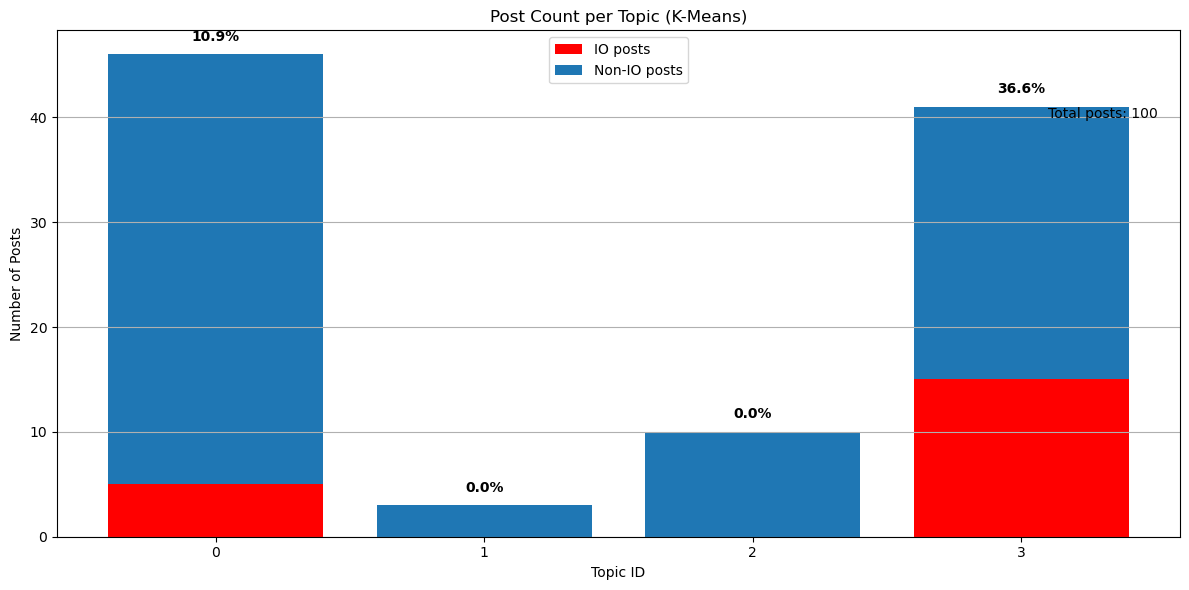

In [34]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

# Named Entity Recognition (NER)

In [35]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [36]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["clean_post_text"].to_list())

In [37]:
df.loc[df["ner_entities"].astype(bool), ["clean_post_text", "ner_entities"]].head()

,clean_post_text,ner_entities
209427,mention_fccd725c68f13d85f3ab5afe1c4f269aaa04c55dda relate w/george upcoming marriage proposal truly surprise endorsed hashtag_holyspirit god!! hashtag_blessedunion !!,[george]
200199,""" mention_c31c0ce8078f5ba5c90c93aa6b5a32975c32fa82b5 : comandante hugo chávez, precursor de la liberación de américa latina url_a8b4f75c94576ea8ba39a908d45515bfa1e207fefb url_824bed881d27c43882779490dab8bef2ea27b2bc9b""","[go ch@@, ación de américa]"
242724,hashtag_jesuisparis hashtag_jesuisparis hashtag_jesuisparis hashtag_jesuisparis ####################,"[jesuisparis, jesuisparis, jesuisparis, jesuisparis]"
210822,let's give positive vibes &amp; hashtag_support 2 mention_f8265eba05e3a55d057c3fb22a7d427b939d3fea91 &amp; hashtag_palestine upcoming hashtag_fifa vote! emoji_smiling_face hashtag_redcardisrael url_6d8cbb605cb9e91e73cfcc088b07d14f604447017f,[palestine]
249498,interesting! child-seat manufacturer dorel utilizes technology found mention_cad8661b7fb8592d186751c40e4852617a9d839b93 race seats. url_7d9a660591f0208084f609c322195006a8598de004,[dorel]


# Entities Statistics

In [38]:
import pandas as pd

def compute_entity_topic_matrix(df, entity_col, topic_col="topic_id", is_control_col="is_control", output_folder_path=None):
    """
    Create a df where values = number of times the entity appears in each topic.

    Args:
        df (pd.DataFrame):
            DataFrame containing posts, entity lists, topic labels and is_control.
        entity_col (str):
            Column containing a list of entities per post.
        topic_col (str):
            Column containing topic labels.
        is_control_col (str):
            Boolean column: True = legitimate, False = IO.

    Returns:
        entity_topic_counts (pd.DataFrame):
            Columns:
                [entity, total_count, io_percent, topic_ids = 1, 2, 3...]
    """

    # 1) Explode entity lists → one row per (entity, topic, is_control)
    df_exp = (
        df[[entity_col, topic_col, is_control_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .copy()
    )

    # 2) Aggregate counts per entity (overall)
    entity_stats = (
        df_exp.groupby(entity_col)
              .agg(
                  total_count=(entity_col, "count"),
                  io_count=(is_control_col, lambda x: (~x).sum()),  # False = IO
              )
              .reset_index()
    )
    entity_stats["io_percent"] = 100 * entity_stats["io_count"] / entity_stats["total_count"]
    entity_stats = entity_stats[[entity_col, "total_count", "io_percent"]]

    # 3) Count occurrences per (entity, topic)
    entity_topic_counts = (
        df_exp.groupby([entity_col, topic_col])
              .size()
              .reset_index(name="count")
    )

    # 4) Pivot to wide format (entity rows × topic columns)
    entity_topic_counts = (
        entity_topic_counts
        .pivot_table(
            index=entity_col,
            columns=topic_col,
            values="count",
            fill_value=0
        )
        .sort_index(axis=1)   # ensure topic columns sorted: 0,1,2,...
        .reset_index()
    )

    # 5) Merge total_count + IO stats
    entity_topic_counts = entity_stats.merge(entity_topic_counts, on=entity_col, how="left")

    # 6) Sort by total_count (descending)
    entity_topic_counts = entity_topic_counts.sort_values("total_count", ascending=False)

    # 7) Save if path provided
    if output_folder_path:
        output_path = Path(output_folder_path) / f"entity_topic_matrix.gzip.parquet"
        df.to_parquet(output_path, index=False, compression="gzip")
        print(f"Saved to {output_path}")

    return entity_topic_counts

In [39]:
import matplotlib.pyplot as plt

def plot_entity_topic_distribution(entity, entity_topic_counts, entity_col, clustering_model="", output_folder_path=None):
    """
    Plot how many times a given entity appears in each topic.
    """

    # Extract row for chosen entity
    row = entity_topic_counts.loc[entity_topic_counts[entity_col] == entity].iloc[0]

    # Keep only topic columns (s)
    topic_cols = [c for c in entity_topic_counts.columns if isinstance(c, int)]
    counts = row[topic_cols]       # Series like [topic_id → count]

    # --- Plot ---
    plt.figure(figsize=(12, 5))
    plt.bar(topic_cols, counts)

    plt.title(f"Topic Distribution for Entity: '{entity}'")
    plt.xlabel("Topic ID")
    plt.ylabel("Count of occurrences")
    plt.xticks(topic_cols)
    plt.grid(axis="y")
    plt.ylim(0, counts.max()* 1.15 ) # y-axis height: 15% padding above the tallest bar
    # Add metadata note (top-right)
    plt.text(
        0.98, 0.92,
        f"clustering model: {clustering_model}\nEntities col: {entity_col}",
        ha="right",
        va="top",
        transform=plt.gca().transAxes
    )

    # plot
    plt.tight_layout()

    # Save if path provided
    if output_folder_path:
        plot_path = output_folder_path / f"{entity}_topic_distribution.png"
        plt.savefig(plot_path, dpi=300)
        print(f"Saved figure to: {plot_path}")

    plt.show()

,ner_entities,total_count,io_percent,-1
22,jesuisparis,4,0.0,4.0
11,ecuador,3,0.0,3.0
2,ana,1,0.0,1.0
0,ación de américa,1,0.0,1.0
3,andy o'brien crosby@@,1,0.0,1.0


Saved figure to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_5/2025_12_01/jesuisparis_topic_distribution.png


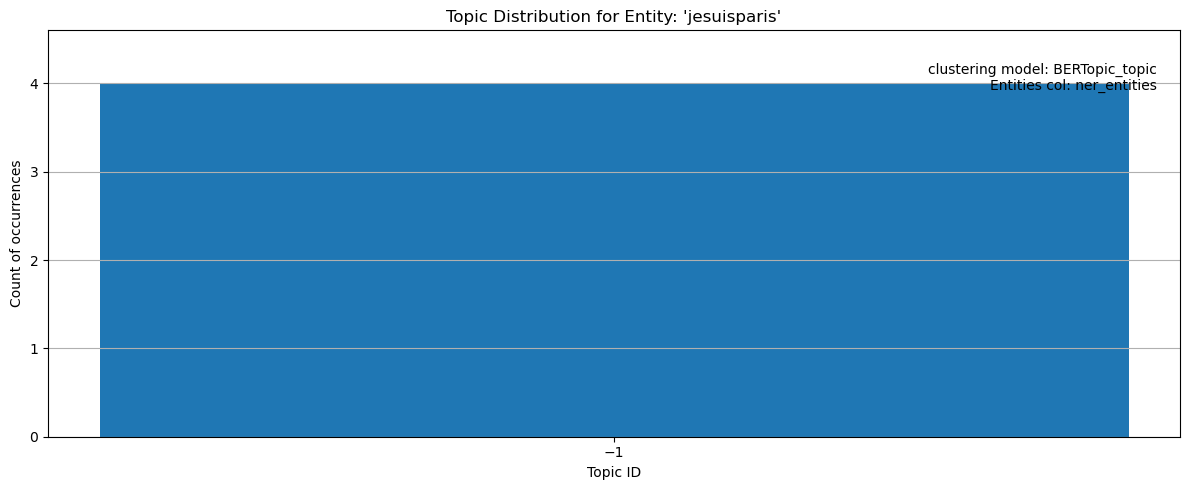

In [40]:
entity_col_name = "ner_entities"
topic_col = "BERTopic_topic"

entity_topic_matrix = compute_entity_topic_matrix(df, entity_col_name, topic_col)
display(entity_topic_matrix.head())

entity = entity_topic_matrix[entity_col_name].iloc[0]   # first entity
plot_entity_topic_distribution(entity=entity, entity_topic_counts=entity_topic_matrix, entity_col=entity_col_name, clustering_model = topic_col, output_folder_path=output_folder_path)

# Save to parquet

In [41]:
# print dataset statistics
for col in df.columns:
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     | bool
clean_post_text                | str
clean_text_no_enteties         | str
translated_post                | str
BERTopic_topic                 | int64
K_Means_topic                  | int32
ner_entities                   | list
